Resample point of streamline and of MAS to be on a uniform grid with a given number of point

In [1]:
import numpy as np
import pandas
from coloraide import Color
import matplotlib.pylab as pl

In [5]:
import sys
sys.path.append('../script/')
from plot_GMM import draw_iso_MAP,draw_aniso_MAP
from from_pandas_to_numpy import pandas_to_numpy_MAT,pandas_to_numpy_MAT_interpolate

In [6]:
path='../data/'
subject = '000001'
name_tract = 'CST_left'
MAT=pandas.read_csv(path+subject+'/07-AugmentedTractsOT/'+name_tract+'_procrusted_avg_clustered_newgrid_ordered_aligned.csv')

In [12]:
i=6
m1,wI1,I1,w1,S1,nb_pts1=pandas_to_numpy_MAT(MAT,nb_MAS=1,streamlineId=[i])
m2,wI2,I2,w2,S2,nb_pts2=pandas_to_numpy_MAT_interpolate(MAT,nb_MAS=1,nb_MAP=10,streamlineId=[i])
ksize=S1.shape[-3]

Text(0.5, 1.0, 'With 10 MAPs')

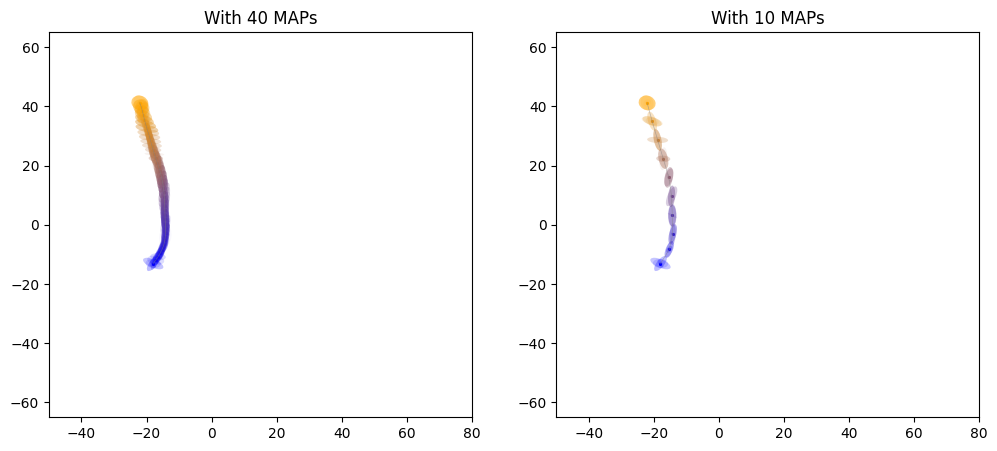

In [15]:
s=1e0
axis=(1,2)
s_aniso=ksize*[100]
s_iso=100
cmap = Color.interpolate(["blue", "orange"],space='srgb')

pl.figure(figsize=(12,5))
pl.subplot(1,2,1)
for j in range(nb_pts1):
    color=cmap(j/(nb_pts1-1))
    draw_iso_MAP(m1[j],wI1[j],I1[j], color=color, alpha=1,s=s,s_iso=s_iso,axis=axis)
    draw_aniso_MAP(m1[j],w1[j],S1[j], color=color, alpha=1,s=s,s_aniso=s_aniso,axis=axis)
pl.plot(m1[:,axis[0]], m1[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-50,-65,130
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.title("With 40 MAPs")

pl.subplot(1,2,2)
for j in range(nb_pts2):
    color=cmap(j/(nb_pts2-1))
    draw_iso_MAP(m2[j],wI2[j],I2[j], color=color, alpha=1,s=s,s_iso=s_iso,axis=axis)
    draw_aniso_MAP(m2[j],w2[j],S2[j], color=color, alpha=1,s=s,s_aniso=s_aniso,axis=axis)
pl.plot(m2[:,axis[0]], m2[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-50,-65,130
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.title("With 10 MAPs")